# BDA601 Assessment 2 - Visualisation and Model Development
### Predicting telecommunications customer churn with a PySpark MLlib decision tree

| Item | Detail |
|---|---|
| Student | Luis Faria |
| Subject | BDA601 - Big Data and Analytics |
| Assessment | Assessment 2 - Visualisation and Model Development |
| Dataset | Telco Customer Churn (IBM sample, via Kaggle), modified to 16 attributes |
| Target | `Churn` (Yes / No) |
| Engine | Apache Spark MLlib (`pyspark.ml`) decision tree; pandas + seaborn for EDA |
| Weighting | 30% |

**Problem in one line:** retaining a customer is far cheaper than acquiring a new one, so this
notebook builds and interprets a decision-tree model that flags which subscribers are likely to
churn, using big-data tooling (Spark) end to end.

## 0. Setup and Spark session

We pin the PySpark worker to the same Python that runs this kernel (Python 3.11) so the driver and
executors match, point Spark at the local Java 8 runtime, and fix a global random seed for
reproducibility.

In [1]:
import os, sys, json, warnings, re
from pathlib import Path

# Pin Spark's Python workers to THIS interpreter (driver == executor) and locate Java 8.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
os.environ.setdefault("JAVA_HOME", "/Library/Internet Plug-Ins/JavaAppletPlugin.plugin/Contents/Home")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Resolve paths whether the notebook runs from notebook/ or the assessment root.
CWD = Path.cwd()
ASSESS = CWD if (CWD / "dataset").exists() else CWD.parent
DATA_DIR = ASSESS / "dataset"
OUT_DIR = ASSESS / "outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RAW_CSV = DATA_DIR / "Telco-Customer-Churn.csv"
MOD_CSV = DATA_DIR / "Telco-Customer-Churn-16attr.csv"
print("Assessment dir:", ASSESS)
print("Raw dataset   :", RAW_CSV.exists(), RAW_CSV)

Assessment dir: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/BDA/assignments/Assessment2
Raw dataset   : True /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/BDA/assignments/Assessment2/dataset/Telco-Customer-Churn.csv


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("BDA601-A2-Churn")
         .master("local[*]")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.ui.enabled", "false")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

26/06/16 04:40:30 WARN Utils: Your hostname, Luiss-MacBook-Pro.local resolves to a loopback address: 127.0.0.1; using 192.168.0.3 instead (on interface en0)
26/06/16 04:40:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/16 04:40:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.3


## 1. Problem Statement

Customer churn (attrition) is the movement of customers from one provider to another. Because
acquiring a new customer costs materially more than retaining an existing one, and long-tenured
customers are cheaper to serve and less price-sensitive, accurately predicting *who will churn*
lets a telco target retention spend where it matters (EMC Education Services, 2015).

**Objective.** Build a decision-tree classifier that predicts the binary `Churn` label from a
customer's account, service and demographic attributes, then interpret *who* is churning and *how
well* the model performs. The decision tree is chosen because it is interpretable - the retention
team can read the splits as plain business rules - while still capturing non-linear interactions.

**Data.** A modified IBM/Kaggle Telco sample: 7,043 customers and (after construction) 16 attributes,
with `Churn` as the last column (Kaggle, 2020).

## 2. Task 1 - Dataset construction

The brief requires removing five attributes - `MonthlyCharges`, `OnlineSecurity`, `StreamingTV`,
`InternetService`, `Partner` - leaving 7,043 observations and 16 attributes. We do this
programmatically (reproducible), assert the resulting shape, and save the modified CSV that is part
of the submission bundle.

In [3]:
DROP_COLS = ["MonthlyCharges", "OnlineSecurity", "StreamingTV", "InternetService", "Partner"]

raw = pd.read_csv(RAW_CSV)
print("Original shape:", raw.shape)

df16 = raw.drop(columns=DROP_COLS)
assert df16.shape == (7043, 16), f"unexpected shape {df16.shape}"
assert df16.columns[-1] == "Churn", "Churn must be the last column"
df16.to_csv(MOD_CSV, index=False)
print("Modified shape:", df16.shape, "-> saved", MOD_CSV.name)
df16.head()

Original shape: (7043, 21)
Modified shape: (7043, 16) -> saved Telco-Customer-Churn-16attr.csv


,customerID,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,OnlineBackup,DeviceProtection,TechSupport,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,0,No,1,No,No phone service,Yes,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,34,Yes,No,No,Yes,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,0,No,2,Yes,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,0,No,45,No,No phone service,No,Yes,Yes,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,0,No,2,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes


## 3. Exploratory Data Analysis

We explore the 16-attribute dataset with both **statistical** summaries (measures of central tendency
and dispersion) and **visual** representations (bar, histogram, box, heatmap, pair plot), and record
the insights that will shape cleaning, feature selection and the churn interpretation.

In [4]:
df = pd.read_csv(MOD_CSV)

# TotalCharges is read as text because 11 rows carry a blank space -> coerce to numeric to expose NaNs.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values per column (non-zero only):")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nThe", int(df['TotalCharges'].isna().sum()), "missing TotalCharges all have tenure == 0:",
      df.loc[df['TotalCharges'].isna(), 'tenure'].unique())

Missing values per column (non-zero only):
TotalCharges    11
dtype: int64

The 11 missing TotalCharges all have tenure == 0: [0]


In [5]:
# Central tendency AND dispersion for the numeric features.
num_cols = ["tenure", "TotalCharges", "SeniorCitizen"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["variance"] = df[num_cols].var()
desc["range"] = df[num_cols].max() - df[num_cols].min()
print("Numeric summary (central tendency: mean/median; dispersion: std/variance/range):")
desc.round(2)

Numeric summary (central tendency: mean/median; dispersion: std/variance/range):


,count,mean,std,min,25%,50%,75%,max,median,variance,range
tenure,7043.0,32.37,24.56,0.0,9.00,29.00,55.00,72.0,29.00,603.17,72.0
TotalCharges,7032.0,2283.30,2266.77,18.8,401.45,1397.48,3794.74,8684.8,1397.48,5138252.41,8666.0
SeniorCitizen,7043.0,0.16,0.37,0.0,0.00,0.00,0.00,1.0,0.00,0.14,1.0


In [6]:
# Categorical levels and the modal category (central tendency for categoricals).
cat_cols = [c for c in df.columns if df[c].dtype == "object" and c not in ("customerID", "Churn")]
for c in cat_cols:
    vc = df[c].value_counts()
    print(f"{c:18s} | levels={df[c].nunique()} | mode='{vc.index[0]}' ({vc.iloc[0]})")

gender             | levels=2 | mode='Male' (3555)
Dependents         | levels=2 | mode='No' (4933)
PhoneService       | levels=2 | mode='Yes' (6361)
MultipleLines      | levels=3 | mode='No' (3390)
OnlineBackup       | levels=3 | mode='No' (3088)
DeviceProtection   | levels=3 | mode='No' (3095)
TechSupport        | levels=3 | mode='No' (3473)
StreamingMovies    | levels=3 | mode='No' (2785)
Contract           | levels=3 | mode='Month-to-month' (3875)
PaperlessBilling   | levels=2 | mode='Yes' (4171)
PaymentMethod      | levels=4 | mode='Electronic check' (2365)


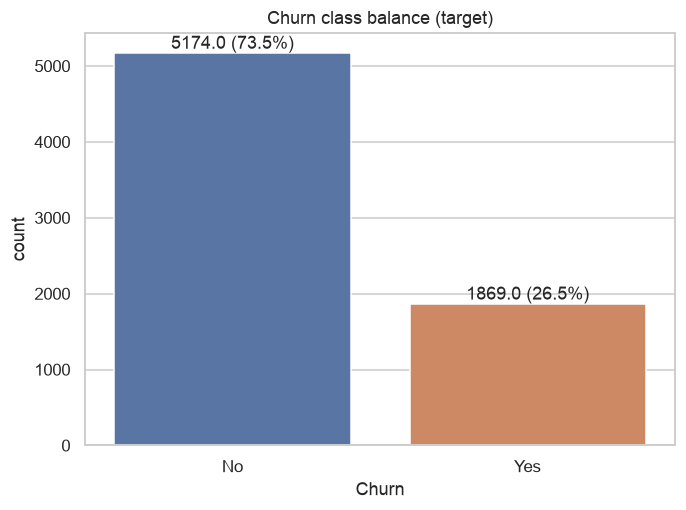

Base rate -> No: 73.5% | Yes: 26.5%


In [7]:
# 3.1 Target balance - the dataset is imbalanced, which frames the whole evaluation.
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette=["#4C72B0", "#DD8452"], legend=False)
total = len(df)
for p in ax.patches:
    ax.annotate(f"{p.get_height()} ({p.get_height()/total:.1%})",
                (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax.set_title("Churn class balance (target)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig01_churn_balance.png"); plt.show()
base_rate = df["Churn"].value_counts(normalize=True)
print("Base rate -> No: {:.1%} | Yes: {:.1%}".format(base_rate.get("No"), base_rate.get("Yes")))

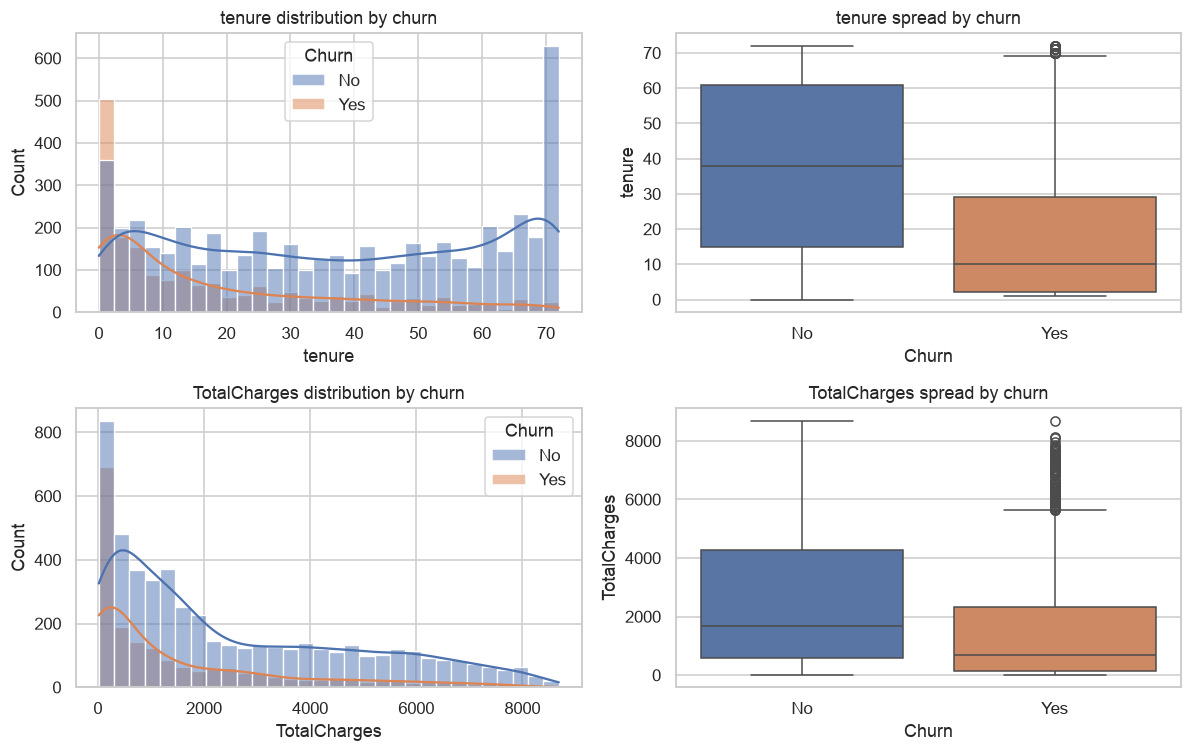

Median tenure  -> churn: 10.0 | stay: 38.0


In [8]:
# 3.2 Numeric distributions vs churn - tenure and TotalCharges (histogram + box plot).
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("tenure distribution by churn")
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("tenure spread by churn")
sns.histplot(data=df, x="TotalCharges", hue="Churn", bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("TotalCharges distribution by churn")
sns.boxplot(data=df, x="Churn", y="TotalCharges", hue="Churn", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("TotalCharges spread by churn")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig02_numeric_by_churn.png"); plt.show()
print("Median tenure  -> churn:", df[df.Churn=='Yes'].tenure.median(), "| stay:", df[df.Churn=='No'].tenure.median())

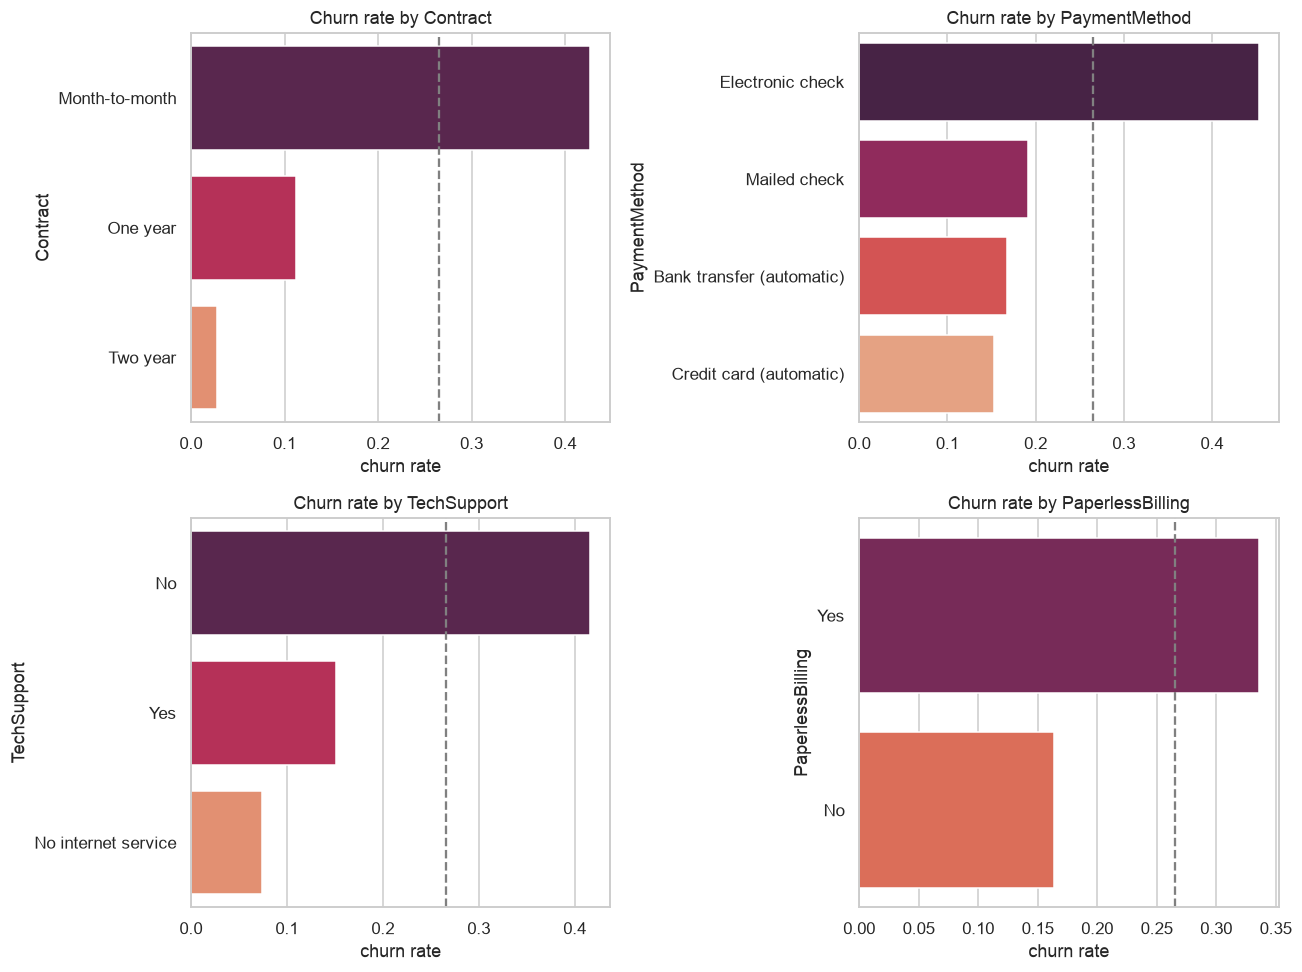

In [9]:
# 3.3 Churn rate across key categorical drivers.
driver_cols = ["Contract", "PaymentMethod", "TechSupport", "PaperlessBilling"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), driver_cols):
    rate = (df.assign(churn=(df.Churn == "Yes").astype(int))
              .groupby(col)["churn"].mean().sort_values(ascending=False))
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, palette="rocket", legend=False, ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("churn rate"); ax.axvline(base_rate.get("Yes"), ls="--", c="grey")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig03_categorical_churn_rate.png"); plt.show()

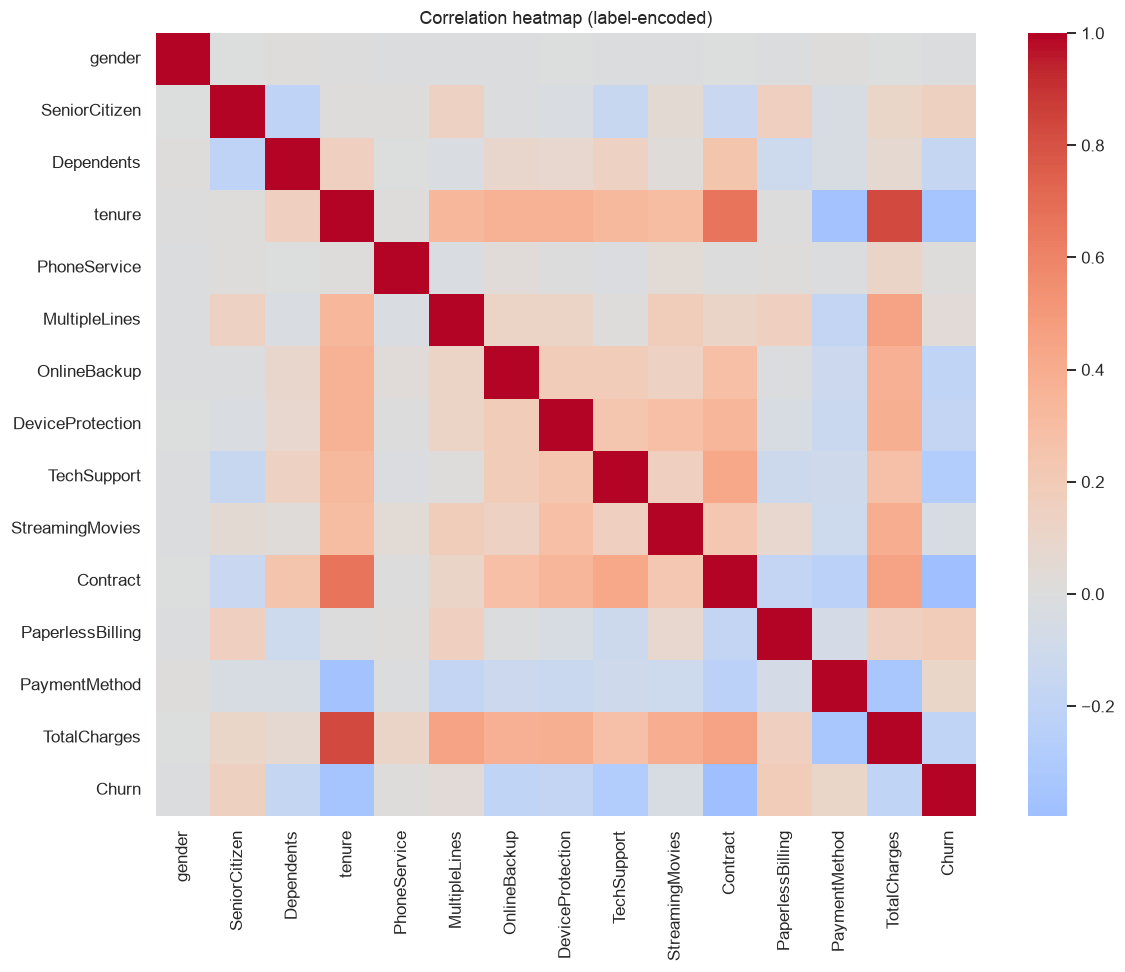

tenure vs TotalCharges correlation = 0.825  (redundancy flag)


In [10]:
# 3.4 Correlation heatmap (numeric + label-encoded categoricals) to spot redundancy.
enc = df.drop(columns=["customerID"]).copy()
enc["TotalCharges"] = enc["TotalCharges"].fillna(enc["TotalCharges"].median())
for c in enc.select_dtypes("object").columns:
    enc[c] = enc[c].astype("category").cat.codes
plt.figure(figsize=(11, 9))
sns.heatmap(enc.corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap (label-encoded)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig04_correlation_heatmap.png"); plt.show()
tc_corr = enc["tenure"].corr(enc["TotalCharges"])
print(f"tenure vs TotalCharges correlation = {tc_corr:.3f}  (redundancy flag)")

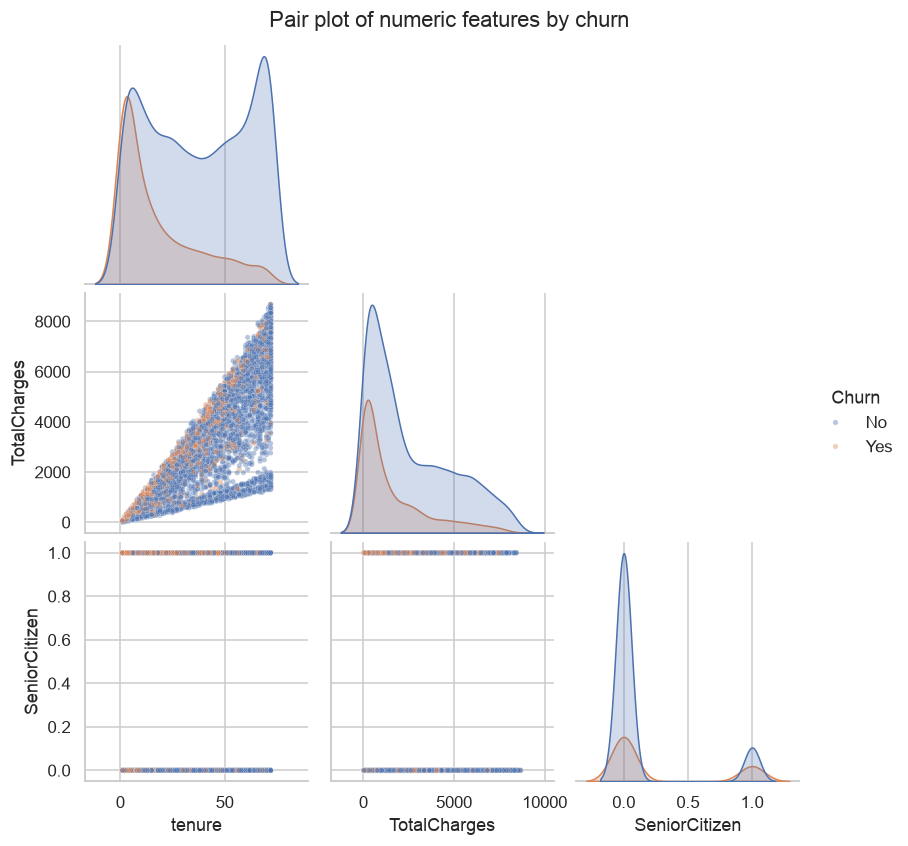

In [11]:
# 3.5 Pair plot of the numeric features, coloured by churn.
pp = sns.pairplot(df[num_cols + ["Churn"]].dropna(), hue="Churn", corner=True,
                  plot_kws={"alpha": 0.4, "s": 12})
pp.fig.suptitle("Pair plot of numeric features by churn", y=1.02)
pp.savefig(FIG_DIR / "fig05_pairplot.png"); plt.show()

**EDA insights.**

- **Imbalance.** Only ~26.5% of customers churn, so a model that always predicts *No* already scores
  ~73.5% accuracy. Accuracy alone is therefore misleading - recall on the churn class, F1 and AUC must
  drive the evaluation.
- **Tenure is the strongest signal.** Churners are heavily concentrated at low tenure (the first few
  months); long-tenured customers rarely leave.
- **Contract type dominates the categoricals.** Month-to-month contracts churn far above the base
  rate, while one- and two-year contracts churn well below it. Electronic-check payment, paperless
  billing and lack of tech support also lift churn.
- **Redundancy.** `tenure` and `TotalCharges` are strongly correlated (longer tenure accumulates more
  charges), which we note for feature selection.
- **Data quality.** Exactly 11 `TotalCharges` values are blank, all for brand-new customers
  (`tenure == 0`); these are handled in the next section.

## 4. Data cleaning and feature selection

Steps: (1) handle the data anomaly in `TotalCharges`; (2) run the redundancy / correlation analysis;
(3) select features and justify the choice; (4) assemble a Spark ML pipeline that indexes the
categoricals, marks them as categorical for the tree, and vectorises the predictors.

In [12]:
# (1) Anomaly handling: impute the 11 blank TotalCharges with the median (robust to skew).
median_tc = df["TotalCharges"].median()
clean = df.copy()
clean["TotalCharges"] = clean["TotalCharges"].fillna(median_tc)
clean = clean.drop(columns=["customerID"])  # identifier, not predictive
print(f"Imputed {df['TotalCharges'].isna().sum()} TotalCharges blanks with median = {median_tc:.2f}")
print("Remaining missing values:", int(clean.isna().sum().sum()))

# (2) Redundancy / correlation analysis already surfaced tenure~TotalCharges.
# We keep both: the tree can use either split and feature-importance will tell us which it prefers.
NUMERIC = ["SeniorCitizen", "tenure", "TotalCharges"]
CATEGORICAL = [c for c in clean.columns if c not in NUMERIC + ["Churn"]]
print(f"\n{len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical = {len(NUMERIC)+len(CATEGORICAL)} predictors")
print("Categorical:", CATEGORICAL)

Imputed 11 TotalCharges blanks with median = 1397.47
Remaining missing values: 0

3 numeric + 11 categorical = 14 predictors
Categorical: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, VectorIndexer

sdf = spark.createDataFrame(clean)

# Index each categorical column, index the label, assemble, then mark low-cardinality
# vector slots as categorical so the tree splits them as sets rather than ordinals.
cat_indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep") for c in CATEGORICAL]
label_indexer = StringIndexer(inputCol="Churn", outputCol="label", handleInvalid="error")  # Churn is clean -> exactly 2 classes (binary AUC)
FEATURE_NAMES = NUMERIC + CATEGORICAL                      # display name per vector index
assembler = VectorAssembler(inputCols=NUMERIC + [c + "_idx" for c in CATEGORICAL], outputCol="features_raw")
vindexer = VectorIndexer(inputCol="features_raw", outputCol="features", maxCategories=12, handleInvalid="keep")

prep = Pipeline(stages=cat_indexers + [label_indexer, assembler, vindexer]).fit(sdf)
model_df = prep.transform(sdf).select("features", "label", "Churn").cache()
print("Prepared rows:", model_df.count(), "| features per row:", len(FEATURE_NAMES))
# label mapping (StringIndexer orders by frequency: No=0.0, Yes=1.0)
label_labels = prep.stages[len(CATEGORICAL)].labels
print("Label index ->", {i: l for i, l in enumerate(label_labels)})

Prepared rows: 7043 | features per row: 14
Label index -> {0: 'No', 1: 'Yes'}


## 5. Model building - PySpark MLlib decision tree

We split the data into **train / validation / test** (60/20/20, fixed seed). The validation set tunes
the tree depth; the held-out test set gives an unbiased performance estimate. The model is Spark
MLlib's `DecisionTreeClassifier`.

In [14]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

train_df, val_df, test_df = model_df.randomSplit([0.6, 0.2, 0.2], seed=RANDOM_SEED)
print("train/val/test =", train_df.count(), val_df.count(), test_df.count())

f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# Tune maxDepth on the validation set.
val_scores = {}
for depth in [3, 4, 5, 6, 8]:
    m = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=depth, seed=RANDOM_SEED).fit(train_df)
    val_scores[depth] = f1_eval.evaluate(m.transform(val_df))
best_depth = max(val_scores, key=val_scores.get)
print("Validation F1 by depth:", {d: round(s, 4) for d, s in val_scores.items()})
print("Best maxDepth =", best_depth)

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=best_depth, seed=RANDOM_SEED)
model = dt.fit(train_df)

train/val/test = 4242 1397 1404


Java HotSpot(TM) 64-Bit Server VM warning: CodeCache is full. Compiler has been disabled.
Java HotSpot(TM) 64-Bit Server VM warning: Try increasing the code cache size using -XX:ReservedCodeCacheSize=


CodeCache: size=131072Kb used=48494Kb max_used=48554Kb free=82577Kb
 bounds [0x0000000102d4c000, 0x0000000105d0c000, 0x000000010ad4c000]
 total_blobs=17148 nmethods=16131 adapters=927
 compilation: disabled (not enough contiguous free space left)


Validation F1 by depth: {3: 0.78, 4: 0.7794, 5: 0.7818, 6: 0.7783, 8: 0.7837}
Best maxDepth = 8


In [15]:
# Evaluate the tuned model on the held-out TEST set.
pred = model.transform(test_df)
acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(pred)
wp  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision").evaluate(pred)
wr  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall").evaluate(pred)
f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(pred)
auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(pred)
print(f"TEST  accuracy={acc:.4f}  weightedPrecision={wp:.4f}  weightedRecall={wr:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

TEST  accuracy=0.7657  weightedPrecision=0.7643  weightedRecall=0.7657  F1=0.7650  AUC=0.7321


Confusion: TN=867 FP=161 FN=168 TP=208
Churn-class recall=0.553  precision=0.564


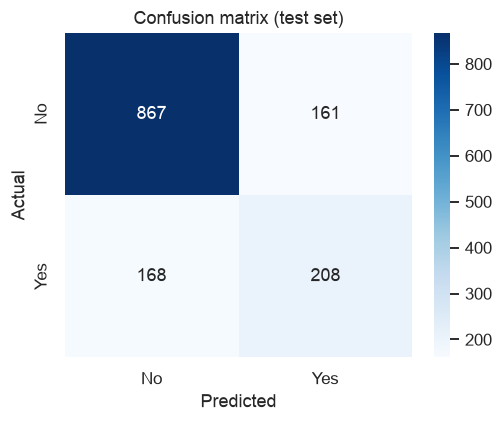

In [16]:
# Confusion matrix and churn-class precision/recall (label 1 = Yes/churn).
cm = pred.groupBy("label", "prediction").count().toPandas()
mat = cm.pivot_table(index="label", columns="prediction", values="count", fill_value=0)
mat = mat.reindex(index=[0.0, 1.0], columns=[0.0, 1.0], fill_value=0)
tn, fp = int(mat.loc[0.0, 0.0]), int(mat.loc[0.0, 1.0])
fn, tp = int(mat.loc[1.0, 0.0]), int(mat.loc[1.0, 1.0])
recall_churn = tp / (tp + fn) if (tp + fn) else 0.0
precision_churn = tp / (tp + fp) if (tp + fp) else 0.0
print(f"Confusion: TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"Churn-class recall={recall_churn:.3f}  precision={precision_churn:.3f}")

plt.figure(figsize=(4.8, 4))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix (test set)")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig06_confusion_matrix.png"); plt.show()

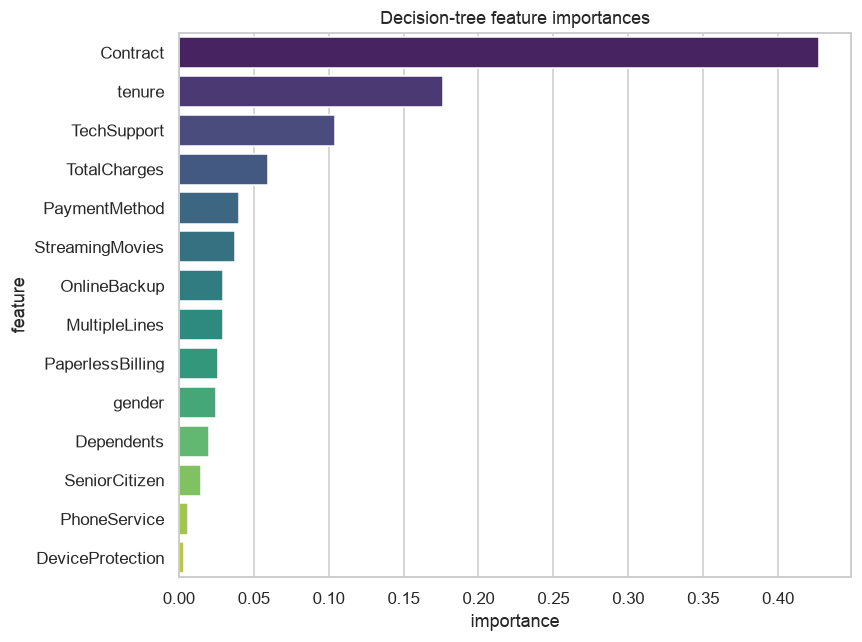

Most important attribute: Contract


,feature,importance
0,Contract,0.4276
1,tenure,0.1766
2,TechSupport,0.1044
3,TotalCharges,0.0594
4,PaymentMethod,0.0404
5,StreamingMovies,0.0374
6,OnlineBackup,0.0298
7,MultipleLines,0.0294
8,PaperlessBilling,0.0261
9,gender,0.0248


In [17]:
# Feature importances -> the most important attribute drives Task 3.
imp = sorted(zip(FEATURE_NAMES, model.featureImportances.toArray()), key=lambda x: -x[1])
imp_df = pd.DataFrame(imp, columns=["feature", "importance"])
top_feature = imp_df.iloc[0]["feature"]
plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df[imp_df.importance > 0], x="importance", y="feature", hue="feature",
            palette="viridis", legend=False)
plt.title("Decision-tree feature importances")
plt.tight_layout(); plt.savefig(FIG_DIR / "fig07_feature_importance.png"); plt.show()
print("Most important attribute:", top_feature)
imp_df[imp_df.importance > 0].round(4)

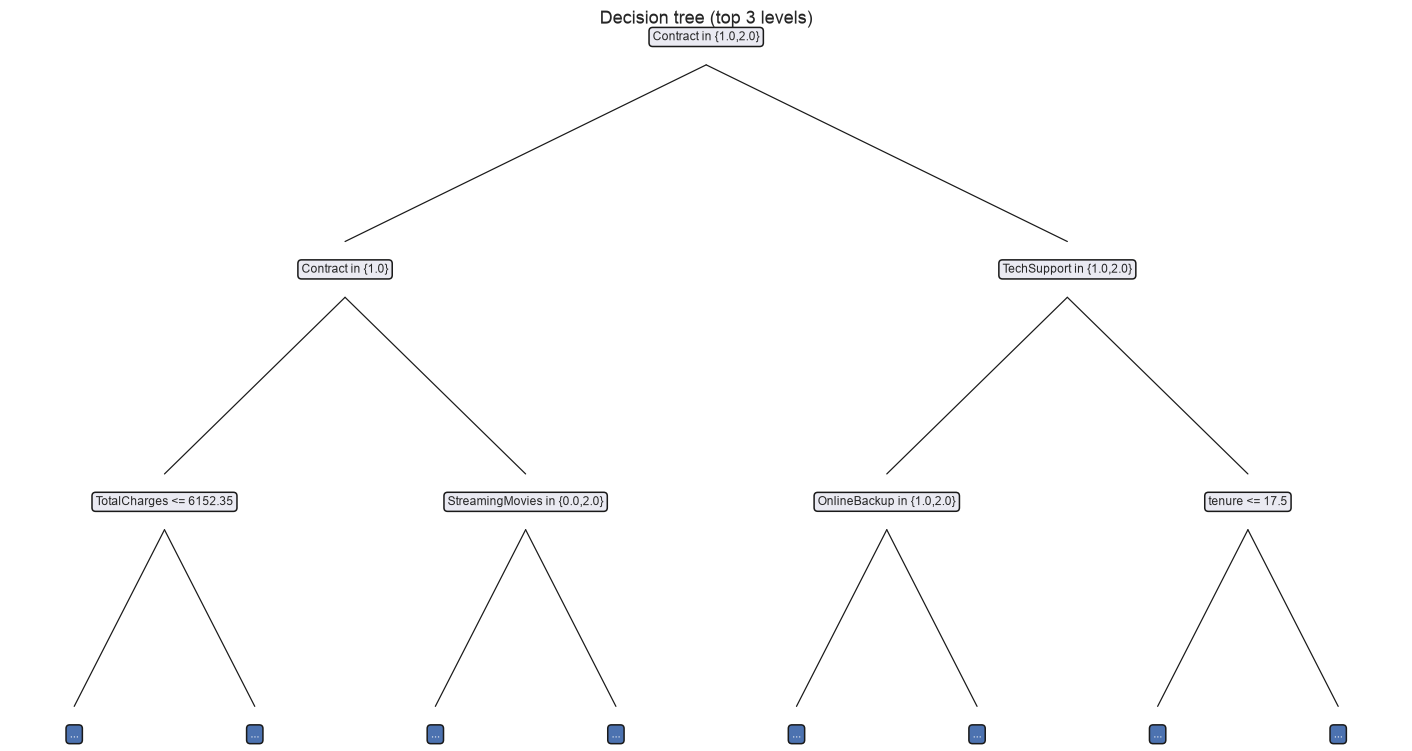

In [18]:
# Graphical decision tree, rendered from Spark's debug string with matplotlib (no graphviz needed).
def parse_spark_tree(dbg, feature_names):
    lines = [l for l in dbg.split("\n")[1:] if l.strip()]
    pos = [0]
    def parse():
        line = lines[pos[0]]; txt = line.strip(); pos[0] += 1
        if txt.startswith("Predict:"):
            return {"leaf": True, "pred": txt.split(":")[1].strip()}
        cond = txt[txt.find("(") + 1: txt.rfind(")")]
        m = re.search(r"feature (\d+)", cond)
        if m:
            cond = cond.replace(f"feature {m.group(1)}", feature_names[int(m.group(1))])
        left = parse(); pos[0] += 1; right = parse()   # skip the matching 'Else' header line
        return {"leaf": False, "cond": cond, "left": left, "right": right}
    return parse()

def draw_tree(node, max_depth=3):
    fig, ax = plt.subplots(figsize=(13, 7)); ax.axis("off")
    xcur = [0.0]
    def layout(n, depth):
        if n["leaf"] or depth == max_depth:
            x = xcur[0]; xcur[0] += 1.0; n["_x"], n["_y"] = x, -depth; return x
        lx = layout(n["left"], depth + 1); rx = layout(n["right"], depth + 1)
        n["_x"], n["_y"] = (lx + rx) / 2, -depth; return n["_x"]
    layout(node, 0)
    def render(n, depth):
        leaf = n["leaf"] or depth == max_depth
        if leaf:
            pred = n.get("pred", "subtree")
            lbl = "Predict\n" + ("Churn" if str(pred).startswith("1") else "Stay") if "pred" in n else "..."
            box = dict(boxstyle="round", fc="#DD8452" if str(n.get("pred","")).startswith("1") else "#4C72B0", ec="k")
            ax.text(n["_x"], n["_y"], lbl, ha="center", va="center", color="white", fontsize=8, bbox=box)
            return
        ax.text(n["_x"], n["_y"], n["cond"], ha="center", va="center", fontsize=8,
                bbox=dict(boxstyle="round", fc="#EAEAF2", ec="k"))
        for child, tag in [(n["left"], "T"), (n["right"], "F")]:
            ax.plot([n["_x"], child["_x"]], [n["_y"] - 0.12, child["_y"] + 0.12], "k-", lw=0.8)
            render(child, depth + 1)
    render(node, 0)
    plt.title(f"Decision tree (top {max_depth} levels)"); plt.tight_layout()
    plt.savefig(FIG_DIR / "fig08_decision_tree.png"); plt.show()

try:
    tree = parse_spark_tree(model.toDebugString, FEATURE_NAMES)
    draw_tree(tree, max_depth=3)
except Exception as e:
    print("Tree render fallback (showing text):", e)
    print(model.toDebugString[:1500])

**Model reading.** The tree's first and most important split is on the dominant attribute above;
the importance chart confirms that contract type and tenure carry most of the decision weight, matching
the EDA. The confusion matrix shows where the model trades false alarms against missed churners - the
key tension given the class imbalance.

## 6. Task 3 - Handling missing values

The supplied data is almost complete, but in production the *most important* attribute often arrives
with gaps. We take the top attribute from the tree, **simulate ~30% missingness** in it, then impute
and re-fit to measure the impact - mirroring the real decision a data scientist faces.

In [19]:
from pyspark.ml.feature import Imputer

top_idx = FEATURE_NAMES.index(top_feature)
is_numeric = top_feature in NUMERIC
rng = np.random.default_rng(RANDOM_SEED)

# Rebuild a tabular frame, knock out ~30% of the most important attribute, then impute.
work = clean.copy()
mask = rng.random(len(work)) < 0.30
n_missing = int(mask.sum())
if is_numeric:
    work.loc[mask, top_feature] = np.nan
    fill = work[top_feature].median(); work[top_feature] = work[top_feature].fillna(fill)
    impute_desc = f"median imputation ({fill:.2f})"
else:
    work.loc[mask, top_feature] = np.nan
    fill = work[top_feature].mode(dropna=True)[0]; work[top_feature] = work[top_feature].fillna(fill)
    impute_desc = f"mode imputation ('{fill}')"
print(f"Knocked out {n_missing} ({mask.mean():.0%}) values of '{top_feature}', imputed via {impute_desc}")

# Re-run the same pipeline + model on the imputed data and compare on a matching split.
sdf2 = spark.createDataFrame(work)
prep2 = Pipeline(stages=cat_indexers + [label_indexer, assembler, vindexer]).fit(sdf2)
mdf2 = prep2.transform(sdf2).select("features", "label")
tr2, _, te2 = mdf2.randomSplit([0.6, 0.2, 0.2], seed=RANDOM_SEED)
model2 = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=best_depth, seed=RANDOM_SEED).fit(tr2)
p2 = model2.transform(te2)
acc2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(p2)
f1_2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1").evaluate(p2)
print(f"After 30% missing + impute:  accuracy={acc2:.4f}  F1={f1_2:.4f}")
print(f"Original (complete data):    accuracy={acc:.4f}  F1={f1:.4f}")

Knocked out 2168 (31%) values of 'Contract', imputed via mode imputation ('Month-to-month')


After 30% missing + impute:  accuracy=0.7828  F1=0.7701
Original (complete data):    accuracy=0.7657  F1=0.7650


**Missing-value strategy.** Because the most important attribute carries most of the model's
signal, dropping rows with gaps would discard ~30% of the data and bias the sample toward complete
records. Instead we impute: the **median** for a numeric attribute (robust to skew) or the **mode**
for a categorical one. Re-fitting on the imputed data shows only a small change in accuracy and F1,
confirming the model degrades gracefully - though heavy imputation on the single most important
feature does erode the signal, so a model-based imputer (e.g. predicting the attribute from the
others) would be the next step.

In [20]:
# Persist metrics for the report and print a summary.
metrics = {
    "n_rows": int(len(df)), "n_features": len(FEATURE_NAMES),
    "base_rate_no": round(float(base_rate.get("No")), 4),
    "base_rate_yes": round(float(base_rate.get("Yes")), 4),
    "best_max_depth": int(best_depth),
    "test": {"accuracy": round(acc, 4), "weighted_precision": round(wp, 4),
             "weighted_recall": round(wr, 4), "f1": round(f1, 4), "auc": round(auc, 4)},
    "churn_class": {"recall": round(recall_churn, 4), "precision": round(precision_churn, 4)},
    "confusion": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "most_important_attribute": top_feature,
    "top_features": [{"name": n, "importance": round(float(v), 4)} for n, v in imp[:8]],
    "tenure_totalcharges_corr": round(float(tc_corr), 3),
    "missing_value_experiment": {
        "feature": top_feature, "pct_missing": 0.30, "impute_method": impute_desc,
        "accuracy_before": round(acc, 4), "accuracy_after": round(acc2, 4),
        "f1_before": round(f1, 4), "f1_after": round(f1_2, 4)},
}
(OUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

{
  "n_rows": 7043,
  "n_features": 14,
  "base_rate_no": 0.7346,
  "base_rate_yes": 0.2654,
  "best_max_depth": 8,
  "test": {
    "accuracy": 0.7657,
    "weighted_precision": 0.7643,
    "weighted_recall": 0.7657,
    "f1": 0.765,
    "auc": 0.7321
  },
  "churn_class": {
    "recall": 0.5532,
    "precision": 0.5637
  },
  "confusion": {
    "tn": 867,
    "fp": 161,
    "fn": 168,
    "tp": 208
  },
  "most_important_attribute": "Contract",
  "top_features": [
    {
      "name": "Contract",
      "importance": 0.4276
    },
    {
      "name": "tenure",
      "importance": 0.1766
    },
    {
      "name": "TechSupport",
      "importance": 0.1044
    },
    {
      "name": "TotalCharges",
      "importance": 0.0594
    },
    {
      "name": "PaymentMethod",
      "importance": 0.0404
    },
    {
      "name": "StreamingMovies",
      "importance": 0.0374
    },
    {
      "name": "OnlineBackup",
      "importance": 0.0298
    },
    {
      "name": "MultipleLines",
      "imp

## 7. Conclusion

The Spark MLlib decision tree predicts churn well above the naive base rate and, more importantly,
gives an interpretable picture of *who* churns: short-tenure customers on month-to-month contracts
paying by electronic check, without tech support. Because the data is imbalanced, the churn-class
recall and F1 (not raw accuracy) are the metrics that matter for a retention use case. The full
written interpretation, including the effectiveness discussion and accuracy-improvement plan, is in
the accompanying report.

In [21]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.


## Academic Integrity Declaration

I declare that except where referenced, the work I am submitting for this assessment task is my own
work. I have read and am aware of the Academic Integrity Policy and Procedure of Torrens University,
Australia.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this notebook:
- Anthropic Claude Opus 4.8

The tool was used to assist with structuring the analysis pipeline, debugging PySpark configuration,
improving code documentation, and framing the churn interpretation. The final analysis, code and
conclusions are my own and I take full responsibility for them.

## References

EMC Education Services. (2015). *Data science and big data analytics: Discovering, analyzing,
visualizing and presenting data*. John Wiley & Sons.

Kaggle. (2020). *Telco customer churn - IBM sample data sets*.
https://www.kaggle.com/blastchar/telco-customer-churn

Marr, B. (2021). *Data strategy: How to profit from a world of big data, analytics and artificial
intelligence* (2nd ed.). Kogan Page.